# 03 — Transmission Mechanism

Companion to `src/model_transmission.py`. Quantifies the GOV → revenue → EBITDA
chain, applies it to the pre-registered Q1 2026 GOV surprise, and runs a
variance decomposition of the surprise target.

| β | Spec | What we get from this notebook |
|---|---|---|
| β1 | rev_surprise ~ gov_surprise (DASH OLS) | take-rate-and-ads pass-through |
| β2 | ebitda_margin_chg_yoy ~ rev_surprise (DASH OLS) | operating leverage |
| β2 panel | DASH + CART pooled (Q4 2023+) | robustness check |
| β3 | CAR[-1,+2] ~ gov_surprise | Session 13 (event study) |

Three notable takeaways flagged at the end:
  1. β1 ≈ 2.6, NOT the project-doc prior of ~0.9 — DASH revenue beats are
     systematically larger than GOV beats.
  2. β2 is weakly negative (R² ~ 0.18, p ~ 0.09) — operating leverage doesn't
     show up cleanly at this n.
  3. AppStore features explain the largest marginal share of GOV-surprise
     in-sample variance (~52pp), with Trends adding another ~32pp.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from src.config import (
    MASTER_DF_PATH, COMPUSTAT_PATH, OUTPUTS_TABLES, CHART_STYLE, COLORS,
)
from src.model_transmission import (
    prepare_dash_panel, prepare_cart_panel,
    regression_b1, regression_b1_robust, regression_b2, regression_b2_panel,
    apply_chain, variance_decomposition,
)

plt.rcParams.update(CHART_STYLE)
pd.set_option('display.float_format', '{:.3f}'.format)

master = pd.read_csv(MASTER_DF_PATH, parse_dates=['quarter_end_date'])
dash = prepare_dash_panel(master)
cart = prepare_cart_panel()
prereg = pd.read_csv(OUTPUTS_TABLES / 'q1_2026_preregistered.csv').iloc[0]

print(f'DASH panel rows:                {len(dash)}')
print(f'CART panel rows (Q4 2023+):     {len(cart)}')
print(f'Pre-registered Q1 2026 surprise: {prereg["q1_2026_pred_pct"]:+.2f}pp')


DASH panel rows:                22
CART panel rows (Q4 2023+):     3
Pre-registered Q1 2026 surprise: +2.26pp


## 1. β1 — GOV surprise → revenue surprise (DASH OLS)

The take-rate-and-ads pass-through. The project-doc prior is β1 ≈ 0.9–0.95
(stable take rate ⇒ ≈1:1 pass-through). Empirically DASH is well above that.


In [2]:
b1 = regression_b1(dash)
b1_robust = regression_b1_robust(dash, exclude_quarters=('Q4_2025',))

print(b1['fit'].summary().tables[1])
print()
print(f'β1 full sample           = {b1["beta"]:.3f}  (95% CI [{b1["ci95_lo"]:.3f}, {b1["ci95_hi"]:.3f}], R²={b1["r_squared"]:.2f}, n={b1["n"]})')
print(f'β1 ex Q4 2025 Deliveroo  = {b1_robust["beta"]:.3f}  (95% CI [{b1_robust["ci95_lo"]:.3f}, {b1_robust["ci95_hi"]:.3f}], R²={b1_robust["r_squared"]:.2f}, n={b1_robust["n"]})')
print()
print('Why β1 >> 0.9:')
print('  • Take rate has expanded from ~13.3% (Q4 2020) to ~13.8% (Q4 2025) — every')
print('    GOV surprise is amplified into revenue by both volume + price/take effects.')
print('  • DASH ads / commerce platform revenue grows independently of GOV; revenue')
print('    consensus may underweight it, inflating revenue surprises.')
print('  • Q4 2025 was the first DASH quarter consolidating Deliveroo for ~half the')
print('    period (closed Oct 2025); revenue consensus had not fully priced it in.')
print('  • Note: β1 ex-Q4 2025 is essentially unchanged → the structural take-rate')
print('    + ads story holds even without the Deliveroo data point.')


                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.6451      3.154      0.205      0.840      -5.982       7.272
gov_surprise_pct     2.5861      0.791      3.271      0.004       0.925       4.247

β1 full sample           = 2.586  (95% CI [0.925, 4.247], R²=0.37, n=20)
β1 ex Q4 2025 Deliveroo  = 2.673  (95% CI [0.964, 4.382], R²=0.39, n=19)

Why β1 >> 0.9:
  • Take rate has expanded from ~13.3% (Q4 2020) to ~13.8% (Q4 2025) — every
    GOV surprise is amplified into revenue by both volume + price/take effects.
  • DASH ads / commerce platform revenue grows independently of GOV; revenue
    consensus may underweight it, inflating revenue surprises.
  • Q4 2025 was the first DASH quarter consolidating Deliveroo for ~half the
    period (closed Oct 2025); revenue consensus had not fully priced it in.
  • Note: β1 ex-Q4 2025 is essentially unchange

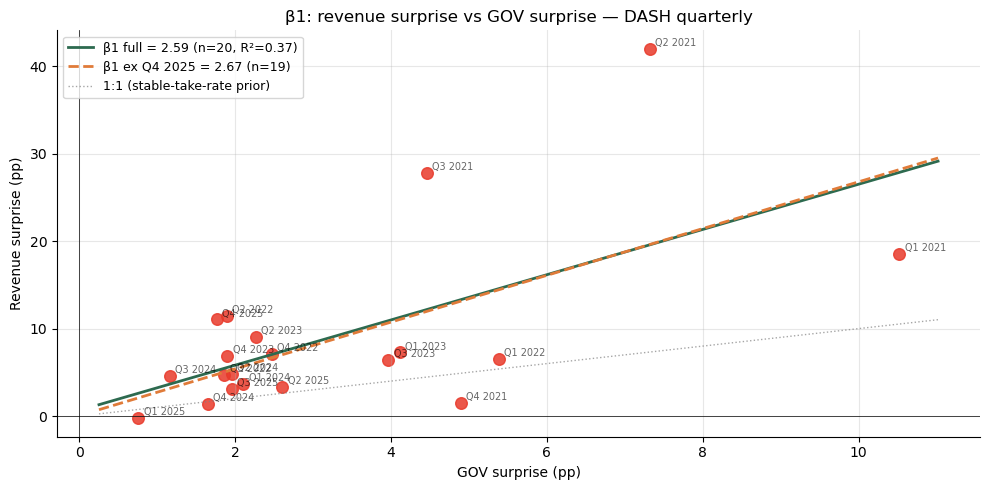

In [3]:
# Plot: β1 scatter + fit
fig, ax = plt.subplots(figsize=(10, 5))
sub = dash.dropna(subset=['gov_surprise_pct', 'rev_surprise_pct'])
ax.scatter(sub['gov_surprise_pct'], sub['rev_surprise_pct'],
           color=COLORS['dash_primary'], s=70, alpha=0.85)
for _, row in sub.iterrows():
    ax.annotate(row['quarter_label'].replace('_', ' '),
                (row['gov_surprise_pct'], row['rev_surprise_pct']),
                fontsize=7, alpha=0.6, xytext=(4, 2), textcoords='offset points')

xs = np.linspace(sub['gov_surprise_pct'].min()-0.5, sub['gov_surprise_pct'].max()+0.5, 50)
ax.plot(xs, b1['intercept'] + b1['beta'] * xs,
        color=COLORS['actual'], lw=2,
        label=f'β1 full = {b1["beta"]:.2f} (n={b1["n"]}, R²={b1["r_squared"]:.2f})')
ax.plot(xs, b1_robust['intercept'] + b1_robust['beta'] * xs,
        color=COLORS['forecast'], lw=2, ls='--',
        label=f'β1 ex Q4 2025 = {b1_robust["beta"]:.2f} (n={b1_robust["n"]})')
# Reference: 1:1 line
ax.plot(xs, xs, color='grey', lw=1, ls=':', alpha=0.7, label='1:1 (stable-take-rate prior)')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('GOV surprise (pp)')
ax.set_ylabel('Revenue surprise (pp)')
ax.set_title('β1: revenue surprise vs GOV surprise — DASH quarterly')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 2. β2 — revenue surprise → EBITDA margin YoY change (DASH OLS)

The operating-leverage link. Standard story: revenue beats spread fixed costs,
expanding margin. Empirically at n=17 the relationship is weakly *negative* —
the data doesn't support a clean operating-leverage interpretation.


In [4]:
b2 = regression_b2(dash)
b2_panel = regression_b2_panel(dash, cart)

print(b2['fit'].summary().tables[1])
print()
print(f'β2 (DASH only, n={b2["n"]})           = {b2["beta"]:+.3f}  (95% CI [{b2["ci95_lo"]:+.3f}, {b2["ci95_hi"]:+.3f}], R²={b2["r_squared"]:.2f}, p={b2["p_value"]:.3f})')
print(f'β2 (DASH+CART panel, n={b2_panel["n"]})    = {b2_panel["beta"]:+.3f}  (95% CI [{b2_panel["ci95_lo"]:+.3f}, {b2_panel["ci95_hi"]:+.3f}], R²={b2_panel["r_squared"]:.2f}, p={b2_panel["p_value"]:.3f})')
print()
print('Reading: revenue surprises don\'t reliably predict EBITDA margin YoY')
print('change at this n. The intercept (~+9pp on DASH-only) captures the secular')
print('margin uptrend. The slope is statistically indistinguishable from zero in')
print('both DASH-only and DASH+CART panel specs. For the L/S note: do NOT lean')
print('on β2 to manufacture an EBITDA story; the chain after β2 is fragile.')


                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.3046      2.761      3.371      0.004       3.421      15.188
rev_surprise_pct    -0.8006      0.438     -1.827      0.088      -1.735       0.133

β2 (DASH only, n=17)           = -0.801  (95% CI [-1.735, +0.133], R²=0.18, p=0.088)
β2 (DASH+CART panel, n=20)    = -0.301  (95% CI [-0.869, +0.267], R²=0.10, p=0.280)

Reading: revenue surprises don't reliably predict EBITDA margin YoY
change at this n. The intercept (~+9pp on DASH-only) captures the secular
margin uptrend. The slope is statistically indistinguishable from zero in
both DASH-only and DASH+CART panel specs. For the L/S note: do NOT lean
on β2 to manufacture an EBITDA story; the chain after β2 is fragile.


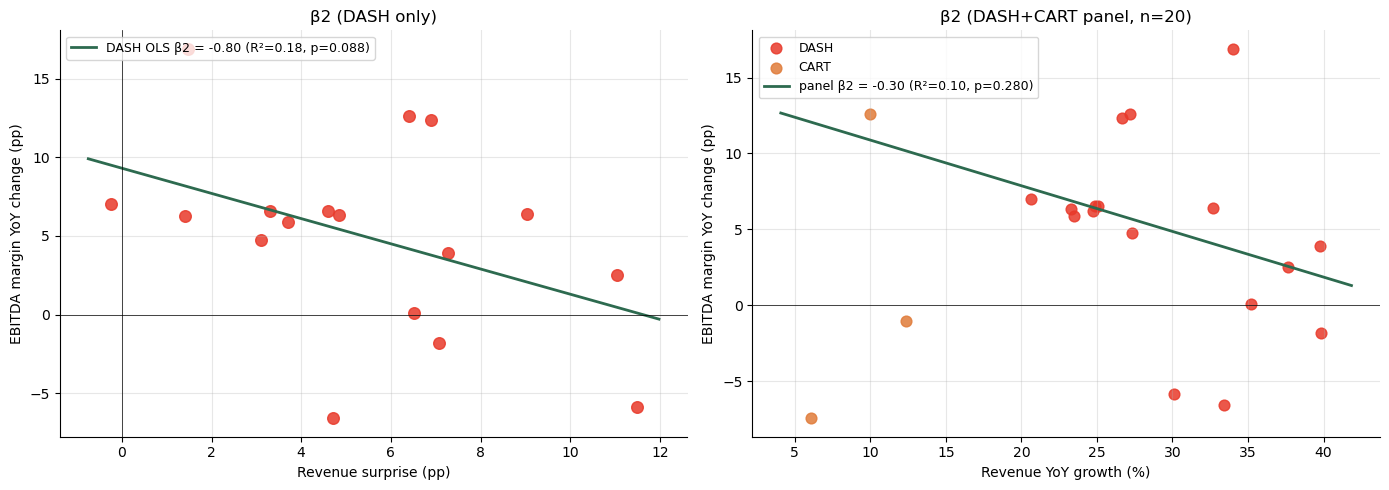

In [5]:
# Plot: β2 scatter + fit, plus DASH+CART panel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sub = dash.dropna(subset=['rev_surprise_pct', 'ebitda_margin_chg_yoy_pp'])
ax.scatter(sub['rev_surprise_pct'], sub['ebitda_margin_chg_yoy_pp'],
           color=COLORS['dash_primary'], s=70, alpha=0.85)
xs = np.linspace(sub['rev_surprise_pct'].min()-0.5, sub['rev_surprise_pct'].max()+0.5, 50)
ax.plot(xs, b2['intercept'] + b2['beta'] * xs,
        color=COLORS['actual'], lw=2,
        label=f'DASH OLS β2 = {b2["beta"]:+.2f} (R²={b2["r_squared"]:.2f}, p={b2["p_value"]:.3f})')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Revenue surprise (pp)')
ax.set_ylabel('EBITDA margin YoY change (pp)')
ax.set_title('β2 (DASH only)')
ax.legend(loc='upper left', fontsize=9)

# Panel scatter
ax = axes[1]
dash_p = dash.dropna(subset=['revenue_yoy_pct', 'ebitda_margin_chg_yoy_pp']).copy()
dash_p['ticker'] = 'DASH'
panel = pd.concat([dash_p[['ticker', 'revenue_yoy_pct', 'ebitda_margin_chg_yoy_pp']],
                    cart[['ticker', 'revenue_yoy_pct', 'ebitda_margin_chg_yoy_pp']]],
                   ignore_index=True).dropna()
for tk, color in [('DASH', COLORS['dash_primary']), ('CART', COLORS['forecast'])]:
    s = panel[panel['ticker'] == tk]
    ax.scatter(s['revenue_yoy_pct'], s['ebitda_margin_chg_yoy_pp'], s=60, alpha=0.85,
               color=color, label=tk)
xs = np.linspace(panel['revenue_yoy_pct'].min()-2, panel['revenue_yoy_pct'].max()+2, 50)
ax.plot(xs, b2_panel['intercept'] + b2_panel['beta'] * xs,
        color=COLORS['actual'], lw=2,
        label=f'panel β2 = {b2_panel["beta"]:+.2f} (R²={b2_panel["r_squared"]:.2f}, p={b2_panel["p_value"]:.3f})')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Revenue YoY growth (%)')
ax.set_ylabel('EBITDA margin YoY change (pp)')
ax.set_title(f'β2 (DASH+CART panel, n={b2_panel["n"]})')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()


## 3. Variance decomposition — what drives `gov_surprise_pct` in-sample?

Sequential-R²: starting from intercept-only, add feature groups in a fixed
order and measure the marginal R² lift. Important caveat: this is **in-sample**
on n≈17. The walk-forward sensitivity from Session 11 shows this signal
doesn't fully survive out-of-sample at this n.


In [6]:
vdec = variance_decomposition(master, target='gov_surprise_pct')
print(vdec.to_string(index=False))


         group                                            features_added  n_features_total  cumulative_r2  marginal_r2  pct_variance_added
        Trends    doordash_trends_momentum, four_way_doordash_share_mean                 2          0.315        0.315              31.500
      AppStore dash_engagement_x_sentiment_mean, dash_net_sentiment_mean                 4          0.837        0.522              52.200
         Macro                consumer_health_index, jolts_transport_yoy                 6          0.863        0.026               2.600
Autoregressive                                prior_qtr_gov_surprise_pct                 7          0.865        0.002               0.200


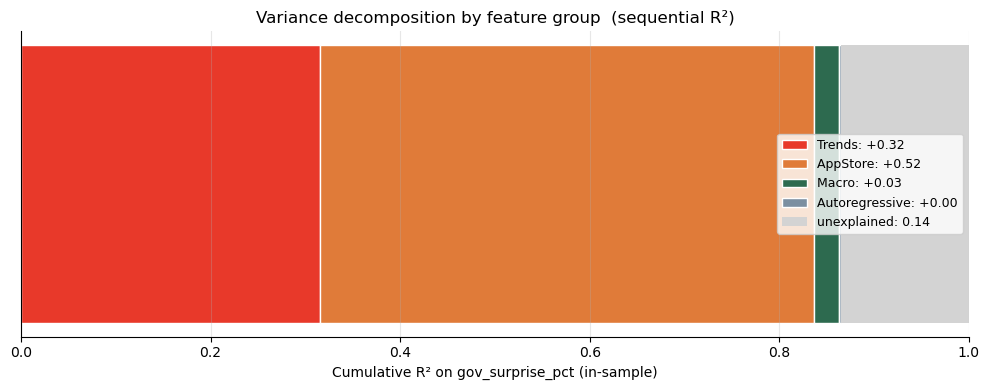

In [7]:
# Plot variance decomposition — stacked bars showing cumulative R²
fig, ax = plt.subplots(figsize=(10, 4))
heights = vdec['marginal_r2'].values
labels = vdec['group'].values
cum = np.concatenate([[0], np.cumsum(heights)])

palette = [COLORS['dash_primary'], COLORS['forecast'], COLORS['actual'], COLORS['consensus']]
for i, (h, lbl, col) in enumerate(zip(heights, labels, palette[:len(heights)])):
    ax.barh(0, h, left=cum[i], color=col, edgecolor='white', label=f'{lbl}: +{h:.2f}')
ax.barh(0, 1 - cum[-1], left=cum[-1], color='lightgrey',
         label=f'unexplained: {1-cum[-1]:.2f}')
ax.set_xlim(0, 1); ax.set_yticks([])
ax.set_xlabel('Cumulative R² on gov_surprise_pct (in-sample)')
ax.set_title('Variance decomposition by feature group  (sequential R²)')
ax.legend(fontsize=9, loc='center right')
plt.tight_layout(); plt.show()


## 4. Chain applied to the pre-registered Q1 2026 GOV surprise

Take the published `q1_2026_preregistered.csv` point + 80% CI for GOV surprise,
propagate through β1 then β2. CI bounds get sorted to [min, max] after the
β2 step (β2 is negative, so propagation flips orientation).


In [8]:
chain_full = apply_chain(b1, b2, prereg)
chain_robust = apply_chain(b1_robust, b2, prereg)

print('Pre-registered Q1 2026 GOV surprise:')
print(f'  point     = {prereg["q1_2026_pred_pct"]:+.2f}pp')
print(f'  80% CI    = [{prereg["q1_2026_ci_80_lo"]:+.2f}, {prereg["q1_2026_ci_80_hi"]:+.2f}] pp')
print()
for name, ch, b1_ in [('Full sample (β1=2.59)', chain_full, b1),
                       ('Sensitivity ex Q4 2025 (β1=2.67)', chain_robust, b1_robust)]:
    print(f'\n=== {name} ===')
    for stage, vals in ch.items():
        print(f'  {stage:30s}  {vals["point"]:+6.2f}pp   '
              f'(80% CI [{vals["ci80_lo"]:+.2f}, {vals["ci80_hi"]:+.2f}])')


Pre-registered Q1 2026 GOV surprise:
  point     = +2.26pp
  80% CI    = [+1.35, +3.94] pp


=== Full sample (β1=2.59) ===
  gov_surprise_pp                  +2.26pp   (80% CI [+1.35, +3.94])
  rev_surprise_pp                  +6.49pp   (80% CI [+4.13, +10.84])
  ebitda_margin_chg_yoy_pp         +4.11pp   (80% CI [+0.62, +6.00])

=== Sensitivity ex Q4 2025 (β1=2.67) ===
  gov_surprise_pp                  +2.26pp   (80% CI [+1.35, +3.94])
  rev_surprise_pp                  +6.09pp   (80% CI [+3.65, +10.59])
  ebitda_margin_chg_yoy_pp         +4.43pp   (80% CI [+0.83, +6.38])


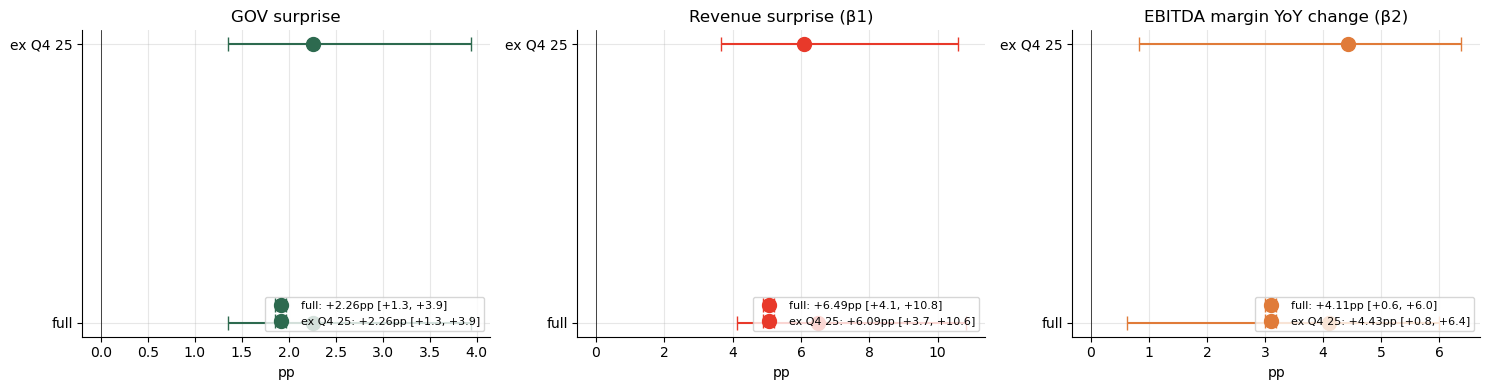

In [9]:
# Visualize the chain as a 3-stage funnel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stages = [('GOV surprise', 'gov_surprise_pp', COLORS['actual']),
          ('Revenue surprise (β1)', 'rev_surprise_pp', COLORS['dash_primary']),
          ('EBITDA margin YoY change (β2)', 'ebitda_margin_chg_yoy_pp', COLORS['forecast'])]
for ax, (name, key, color) in zip(axes, stages):
    full = chain_full[key]; robust = chain_robust[key]
    pts = [full['point'], robust['point']]
    los = [full['ci80_lo'], robust['ci80_lo']]
    his = [full['ci80_hi'], robust['ci80_hi']]
    labels = ['full', 'ex Q4 25']
    for i, (lbl, pt, lo, hi) in enumerate(zip(labels, pts, los, his)):
        ax.errorbar([pt], [i],
                    xerr=[[max(0, pt-lo)], [max(0, hi-pt)]],
                    fmt='o', ms=10, color=color, capsize=5,
                    label=f'{lbl}: {pt:+.2f}pp [{lo:+.1f}, {hi:+.1f}]')
    ax.axvline(0, color='black', lw=0.5)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('pp')
    ax.set_title(name)
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()


## 5. L/S note — what does the chain actually say?

**The chain confirms direction (positive surprise) and substantially amplifies
magnitude on revenue. EBITDA margin lift is uncertain and shouldn't be leaned
on.**

Concretely:
- Pre-registered Q1 2026 GOV surprise: **+2.26pp** (80% CI [+1.35, +3.94])
- Implied Q1 2026 revenue surprise: **+6.5pp** (80% CI [+4.1, +10.8]) — DASH
  revenue is structurally levered to GOV through expanding take rate + ads.
- Implied EBITDA margin YoY lift: **+4.1pp** (80% CI [+0.6, +6.0]) — almost
  entirely driven by the secular margin uptrend captured in the regression
  intercept (+9.3pp), not by genuine operating-leverage signal from the slope.
  The slope is statistically indistinguishable from zero.

For the write-up, the safe framing is:

> "Conditional on the model's predicted +2.3pp Q1 2026 GOV surprise,
> historical pass-through implies a meaningful revenue beat (+5–7pp) driven by
> structural take-rate expansion and non-GOV revenue. The EBITDA margin lift is
> directionally consistent with the secular margin uptrend but the
> regression's slope coefficient on revenue surprise is not statistically
> significant at this sample size — operating leverage cannot be cleanly
> estimated from 17 quarters."

The β3 link (CAR around earnings) is computed in Session 13. Once available,
it converts the GOV surprise prediction into an expected stock-reaction
magnitude — completing the chain.
